In [267]:
# Enable inline figure display and import necessary libraries
%matplotlib inline

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [268]:
# Visual configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans', 'Arial'
plt.rcParams['axes.edgecolor'] = '#d0d7de'
plt.rcParams['axes.linewidth'] = 0.8

1. DATA INGESTION & QUALITY AUDIT

In [270]:
df = pd.read_csv("/Users/divya_kanani/Desktop/ed_patient_data.csv")

print('=' * 60)
print('DATASET HEALTH CHECK')
print('=' * 60)
print(f'Total Records: {len(df):,}')
print(f'Unique Visits: {df["visit_id"].nunique():,}')
print(f'Unique Patients: {df["patient_id"].nunique():,}')
print(f'Missing Values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
print('=' * 60)

DATASET HEALTH CHECK
Total Records: 10,000
Unique Visits: 10,000
Unique Patients: 10,000
Missing Values:
Series([], dtype: int64)


 2. DATA CLEANING & DOMAIN FEATURE ENGINEERING

In [272]:
# Convert timestamps
df['arrival_datetime'] = pd.to_datetime(df['arrival_datetime'])

# Operational Metric: Total Door-to-Doctor Wait
df['door_to_doctor_min'] = (
    df['wait_time_triage_min'] + df['wait_time_doctor_min']
)


In [273]:
# Patient Flow & Clinical Classifications
df['is_admitted'] = (df['disposition'] == 'Admitted').astype(int)
df['is_ama'] = (df['disposition'] == 'AMA').astype(int)  # Against Medical Advice
df['is_excessive_wait'] = (df['wait_time_doctor_min'] > 120).astype(int)

# Arrival Queue Interval: Time elapsed since the previous patient arrived
df = df.sort_values('arrival_datetime').reset_index(drop=True)
df['minutes_since_last_arrival'] = (
    df['arrival_datetime'].diff().dt.total_seconds() / 60.0
)

In [274]:
# Triage Urgency Category Labeling
triage_labels = {
    1: '1 - Resuscitation',
    2: '2 - Emergent',
    3: '3 - Urgent',
    4: '4 - Less Urgent',
    5: '5 - Non-Urgent',
}
df['triage_category'] = df['triage_level'].map(triage_labels)

In [275]:
df.head()

,visit_id,patient_id,arrival_datetime,triage_level,chief_complaint,department,attending_physician,patient_age,patient_gender,insurance_type,...,arrival_hour,arrival_dayofweek,arrival_month,age_group,door_to_doctor_min,is_admitted,is_ama,is_excessive_wait,minutes_since_last_arrival,triage_category
0,VT000001,PT000001,2023-01-01 04:16:54,3,Head injury,Pediatrics,Dr.ZA,68,Male,Medicare,...,4,Sunday,1,65+,78.3,0,0,0,NaN,3 - Urgent
1,VT000002,PT000002,2023-01-01 05:30:57,4,Mild fever,Pediatrics,Dr.DB,56,Female,Medicare,...,5,Sunday,1,50-64,108.0,0,0,0,74.050000,4 - Less Urgent
2,VT000003,PT000003,2023-01-01 07:20:48,4,Laceration,Emergency,Dr.BA,11,Female,Private,...,7,Sunday,1,0-17,105.0,0,0,0,109.850000,4 - Less Urgent
3,VT000004,PT000004,2023-01-01 07:38:58,2,Altered consciousness,Pediatrics,Dr.IA,6,Male,Medicaid,...,7,Sunday,1,0-17,57.6,1,0,0,18.166667,2 - Emergent
4,VT000005,PT000005,2023-01-01 08:35:48,4,Laceration,Orthopedics,Dr.CB,7,Female,Private,...,8,Sunday,1,0-17,124.7,0,0,0,56.833333,4 - Less Urgent


3. EXECUTIVE KPI AGGREGATION

In [277]:
kpis = {
    'Total ER Visits': len(df),
    'Unique Patients': df['patient_id'].nunique(),
    'Avg Door-to-Doctor (min)': round(df['door_to_doctor_min'].mean(), 2),
    'Median Doctor Wait (min)': round(df['wait_time_doctor_min'].median(), 2),
    'Avg Length of Stay (hrs)': round(df['length_of_stay_hrs'].mean(), 2),
    'Hospital Admission Rate (%)': round(df['is_admitted'].mean() * 100, 2),
    'AMA Walkout Rate (%)': round(df['is_ama'].mean() * 100, 2),
    '30-Day Readmission Rate (%)': round(
        df['readmitted_30d'].mean() * 100, 2
    ),
    'Avg Patient Satisfaction (1-10)': round(
        df['satisfaction_score'].mean(), 2
    ),
    'Total Billed Revenue ($ USD)': f"${df['billed_amount_usd'].sum():,.2f}",
}

In [278]:
print('\n' + '=' * 60)
print('EXECUTIVE OPERATIONAL KPIS')
print('=' * 60)
for k, v in kpis.items():
    print(f'{k:<35}: {v}')
print('=' * 60)


EXECUTIVE OPERATIONAL KPIS
Total ER Visits                    : 10000
Unique Patients                    : 10000
Avg Door-to-Doctor (min)           : 78.87
Median Doctor Wait (min)           : 39.4
Avg Length of Stay (hrs)           : 3.26
Hospital Admission Rate (%)        : 21.17
AMA Walkout Rate (%)               : 5.41
30-Day Readmission Rate (%)        : 12.81
Avg Patient Satisfaction (1-10)    : 6.18
Total Billed Revenue ($ USD)       : $44,684,130.75


4. BOTTLENECK & THROUGHPUT ANALYSIS TABLES

In [280]:
# A. Clinical Triage Adherence Breakdown
triage_table = (
    df.groupby('triage_category')
    .agg(
        total_visits=('visit_id', 'count'),
        avg_triage_wait=('wait_time_triage_min', 'mean'),
        avg_doc_wait=('wait_time_doctor_min', 'mean'),
        avg_door_to_doc=('door_to_doctor_min', 'mean'),
        avg_los_hrs=('length_of_stay_hrs', 'mean'),
        admission_pct=('is_admitted', lambda x: round(x.mean() * 100, 2)),
        avg_satisfaction=('satisfaction_score', 'mean'),
    )
    .round(2)
)

print('\n[THROUGHPUT BY TRIAGE ACUITY]')
print(triage_table)


[THROUGHPUT BY TRIAGE ACUITY]
                   total_visits  avg_triage_wait  avg_doc_wait  \
triage_category                                                  
1 - Resuscitation           462             5.45         17.89   
2 - Emergent               1442            10.40         26.92   
3 - Urgent                 3497            19.11         48.10   
4 - Less Urgent            3080            22.71         75.21   
5 - Non-Urgent             1519            25.23         98.21   

                   avg_door_to_doc  avg_los_hrs  admission_pct  \
triage_category                                                  
1 - Resuscitation            23.34         5.84          67.97   
2 - Emergent                 37.32         4.94          56.59   
3 - Urgent                   67.21         3.62          28.22   
4 - Less Urgent              97.92         2.52           0.00   
5 - Non-Urgent              123.44         1.54           0.00   

                   avg_satisfaction  
triag

In [281]:
# B. Root Cause: Patients Leaving Against Medical Advice (AMA)
ama_table = (
    df.groupby('disposition')
    .agg(
        patient_count=('visit_id', 'count'),
        avg_doc_wait_min=('wait_time_doctor_min', 'mean'),
        pct_waited_over_2hrs=(
            'is_excessive_wait',
            lambda x: round(x.mean() * 100, 2),
        ),
        avg_satisfaction=('satisfaction_score', 'mean'),
    )
    .round(2)
)

print('\n[DISPOSITION & WALKOUT ANALYSIS]')
print(ama_table)


[DISPOSITION & WALKOUT ANALYSIS]
                 patient_count  avg_doc_wait_min  pct_waited_over_2hrs  \
disposition                                                              
AMA                        541             65.41                 16.27   
Admitted                  2117             35.65                  3.31   
Discharged home           6982             68.28                 16.99   
Expired                     37             16.71                  0.00   
Transferred                323             24.55                  0.00   

                 avg_satisfaction  
disposition                        
AMA                          6.02  
Admitted                     6.70  
Discharged home              6.00  
Expired                      7.23  
Transferred                  6.89  


In [282]:
# C. Department-Level Efficiency Benchmark
dept_table = (
    df.groupby('department')
    .agg(
        patient_volume=('visit_id', 'count'),
        avg_doc_wait_min=('wait_time_doctor_min', 'mean'),
        avg_los_hrs=('length_of_stay_hrs', 'mean'),
        avg_billed_usd=('billed_amount_usd', 'mean'),
        avg_satisfaction=('satisfaction_score', 'mean'),
    )
    .round(2)
    .sort_values(by='patient_volume', ascending=False)
)

print('\n[DEPARTMENT OPERATIONAL PERFORMANCE]')
print(dept_table)


[DEPARTMENT OPERATIONAL PERFORMANCE]
                 patient_volume  avg_doc_wait_min  avg_los_hrs  \
department                                                       
Emergency                  2792             59.84         3.25   
Cardiology                 1333             61.31         3.20   
Orthopedics                1229             58.45         3.41   
Neurology                  1007             61.16         3.15   
Pediatrics                  981             57.38         3.26   
Obs & Gynae                 859             59.00         3.20   
Trauma                      830             59.10         3.32   
General Surgery             581             59.94         3.30   
Psychiatry                  388             59.42         3.23   

                 avg_billed_usd  avg_satisfaction  
department                                         
Emergency               3711.31              6.18  
Cardiology              4984.85              6.17  
Orthopedics             490

5. VISUALIZATIONS 

In [284]:
# Figure 1: Overview Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# 1: Doctor Wait Time vs Patient Satisfaction (Correlation & Dropoff)
sns.regplot(
    data=df,
    x='wait_time_doctor_min',
    y='satisfaction_score',
    ax=axes[0, 0],
    color='#1f77b4',
    scatter_kws={'alpha': 0.55, 's': 40},
    line_kws={'color': '#d62728', 'linewidth': 2},
)
axes[0, 0].axvline(
    120,
    color='#d62728',
    linestyle='--',
    alpha=0.8,
    label='Critical Delay Threshold (120m)',
)
axes[0, 0].set_title(
    'Impact of Wait Time on Patient Satisfaction',
    fontsize=13,
    fontweight='bold',
)
axes[0, 0].set_xlabel('Doctor Wait Time (Minutes)', fontsize=11)
axes[0, 0].set_ylabel('Satisfaction Score (1-10)', fontsize=11)
axes[0, 0].legend()

In [285]:
# 2: Hourly Inflow Surge vs Average Doctor Wait Times
hourly = (
    df.groupby('arrival_hour')
    .agg(
        inflow=('visit_id', 'count'),
        avg_wait=('wait_time_doctor_min', 'mean'),
    )
    .reset_index()
)

ax2_twin = axes[0, 1].twinx()
sns.barplot(
    data=hourly,
    x='arrival_hour',
    y='inflow',
    ax=axes[0, 1],
    color='#4c72b0',
    alpha=0.75,
)
sns.lineplot(
    data=hourly,
    x=hourly.index,
    y='avg_wait',
    ax=ax2_twin,
    color='#c44e52',
    marker='o',
    linewidth=2.5,
)
axes[0, 1].set_title(
    'Hourly Arrival Volume vs Doctor Wait Time Delays',
    fontsize=13,
    fontweight='bold',
)
axes[0, 1].set_xlabel('Hour of Day (0 - 23)', fontsize=11)
axes[0, 1].set_ylabel('Total Patient Arrivals', fontsize=11)
ax2_twin.set_ylabel(
    'Avg Wait Time (Minutes)', color='#c44e52', fontsize=11
)
ax2_twin.grid(False) 

In [286]:
# 3: Length of Stay (LOS) by Triage Acuity
sns.boxplot(
    data=df.sort_values('triage_level'),
    x='triage_category',
    y='length_of_stay_hrs',
    hue='triage_category',
    ax=axes[1, 0],
    palette='Blues_r',
    legend=False,
)
axes[1, 0].set_title(
    'Length of Stay (LOS) Distribution by Triage Acuity',
    fontsize=13,
    fontweight='bold',
)
axes[1, 0].set_xlabel('Clinical Triage Level', fontsize=11)
axes[1, 0].set_ylabel('Length of Stay (Hours)', fontsize=11)
axes[1, 0].tick_params(axis='x', rotation=15)


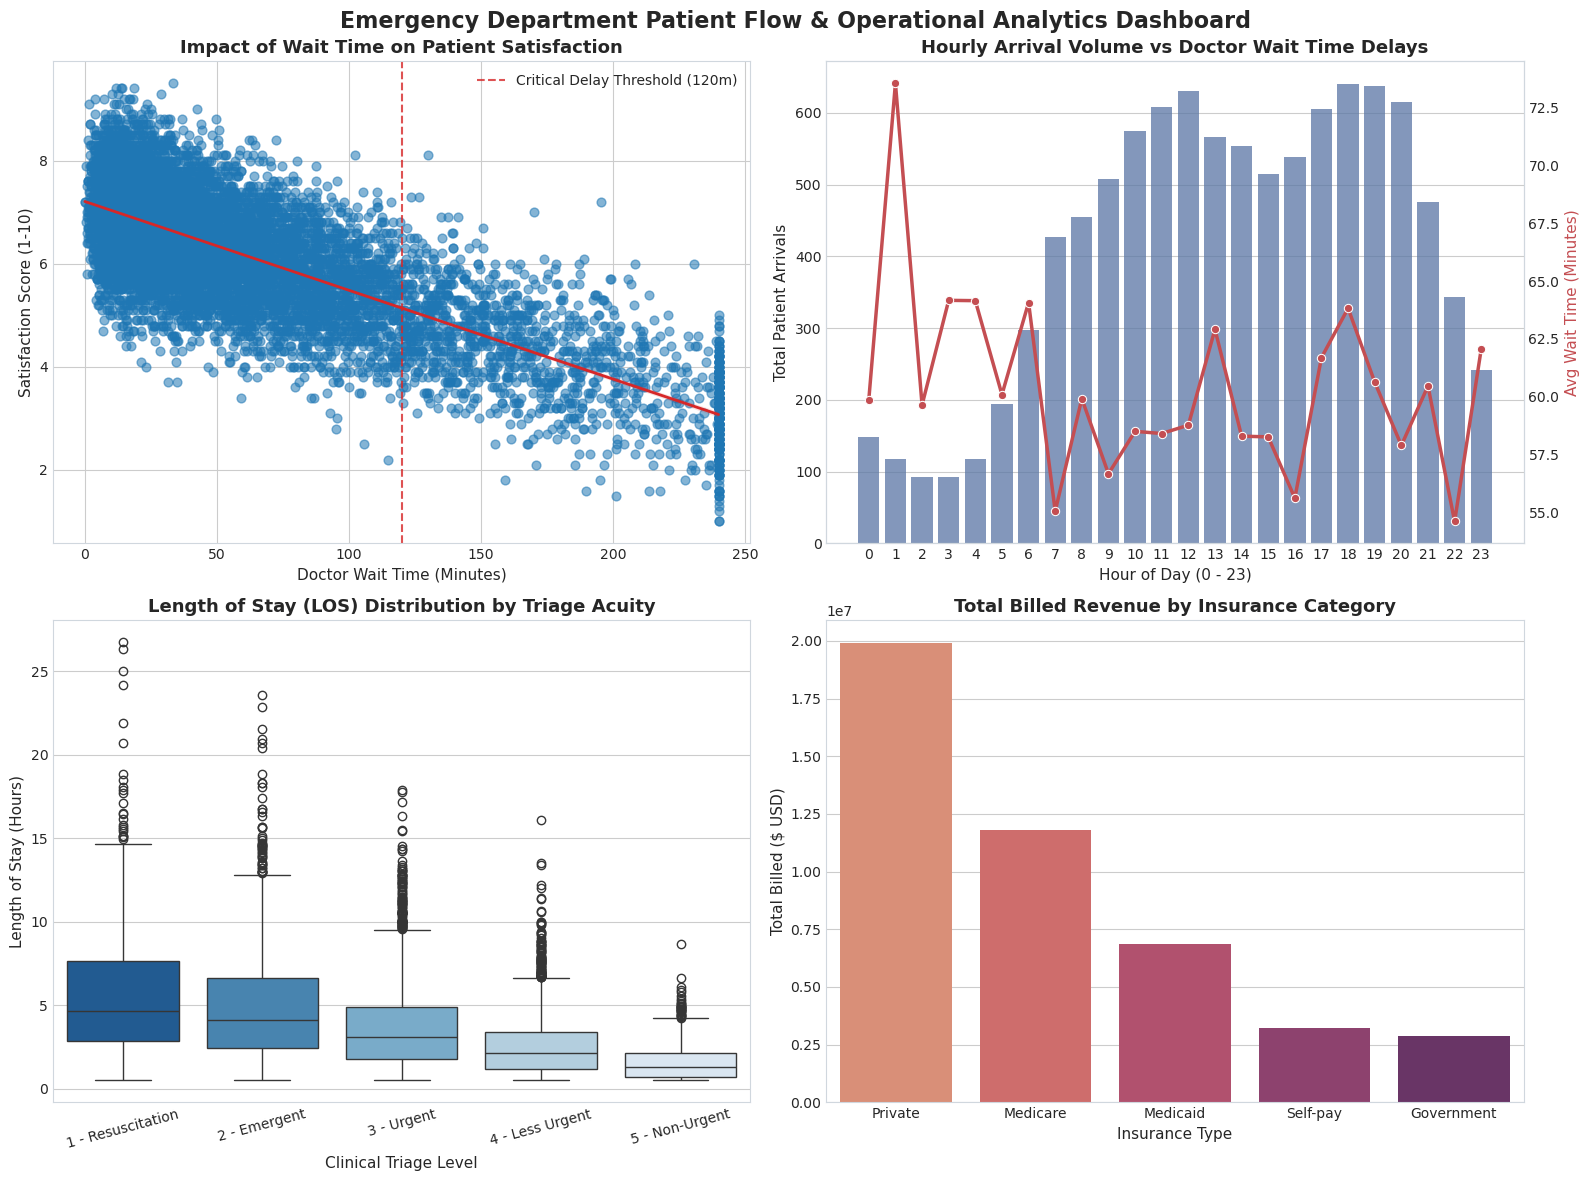

In [287]:
# 4: Revenue Realization & Readmission Rate by Payer Mix
payer = (
    df.groupby('insurance_type')
    .agg(
        total_billed=('billed_amount_usd', 'sum'),
        readmit_pct=('readmitted_30d', lambda x: x.mean() * 100),
    )
    .reset_index()
    .sort_values(by='total_billed', ascending=False)
)

sns.barplot(
    data=payer,
    x='insurance_type',
    y='total_billed',
    hue='insurance_type',
    ax=axes[1, 1],
    palette='flare',
    legend=False,
)
axes[1, 1].set_title(
    'Total Billed Revenue by Insurance Category',
    fontsize=13,
    fontweight='bold',
)
axes[1, 1].set_xlabel('Insurance Type', fontsize=11)
axes[1, 1].set_ylabel('Total Billed ($ USD)', fontsize=11)

plt.suptitle(
    'Emergency Department Patient Flow & Operational Analytics Dashboard',
    fontsize=16,
    fontweight='heavy',
    y=0.98,
)
plt.tight_layout()

# save a copy and display
plt.savefig('ed_operational_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()


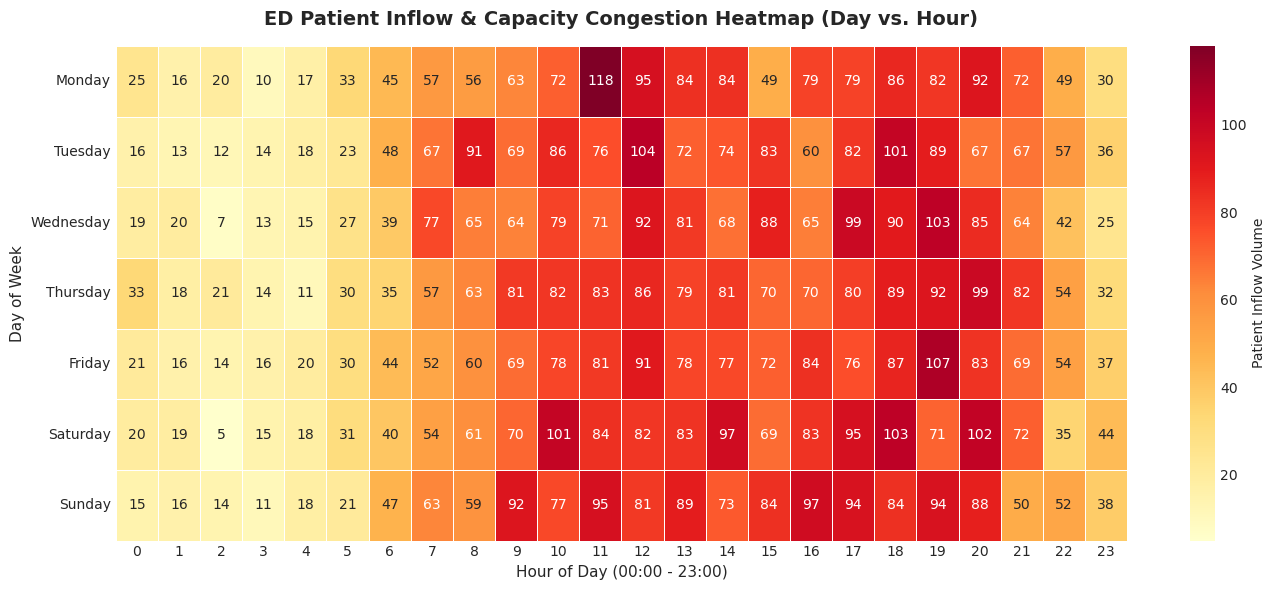


[COMPLETE] Visual charts generated: "ed_operational_dashboard.png" & "ed_capacity_heatmap.png"


In [288]:
# Figure 2: Day x Hour Capacity & Congestion Heatmap
days_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday',
]
heatmap_matrix = (
    df.pivot_table(
        index='arrival_dayofweek',
        columns='arrival_hour',
        values='visit_id',
        aggfunc='count',
        fill_value=0,
    )
    .reindex(days_order)
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap_matrix,
    cmap='YlOrRd',
    annot=True,
    fmt='d',
    cbar_kws={'label': 'Patient Inflow Volume'},
    linewidths=0.5,
)
plt.title(
    'ED Patient Inflow & Capacity Congestion Heatmap (Day vs. Hour)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Hour of Day (00:00 - 23:00)', fontsize=11)
plt.ylabel('Day of Week', fontsize=11)
plt.tight_layout()

# Save a copy and display 
plt.savefig('ed_capacity_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print(
    '\n[COMPLETE] Visual charts generated: "ed_operational_dashboard.png" & "ed_capacity_heatmap.png"'
)